In [1]:
import os
import numpy as np
from custom_unet import CustomUNet


2025-06-19 19:32:56.764664: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-19 19:32:56.800287: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750375976.857461 1697348 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750375976.877604 1697348 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750375976.919821 1697348 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# Paths
test_image_folder = "/hpcstor6/scratch01/a/a.kanamarlapudi001/datasets/splits/test/images"
test_mask_folder  = "/hpcstor6/scratch01/a/a.kanamarlapudi001/datasets/splits/test/masks"
model_weights_path = "/hpcstor6/scratch01/a/a.kanamarlapudi001/datasets/model_weights_50.weights.h5"


In [3]:
# Load UNet and weights
unet = CustomUNet(
    img_height=512,
    img_width=512,
    batch_size=8,
    train_image_dir=None,
    train_mask_dir=None,
    val_image_dir=None,
    val_mask_dir=None,
    test_image_dir=test_image_folder,
    test_mask_dir=test_mask_folder,
    save_model_path=model_weights_path,
)

unet.model.load_weights(model_weights_path)
print("✅ Model weights loaded!")


2025-06-19 19:33:09.011335: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_SYSTEM_DRIVER_MISMATCH: system has unsupported display driver / cuda driver combination


✅ Model weights loaded!


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/291 [00:00<?, ?it/s]

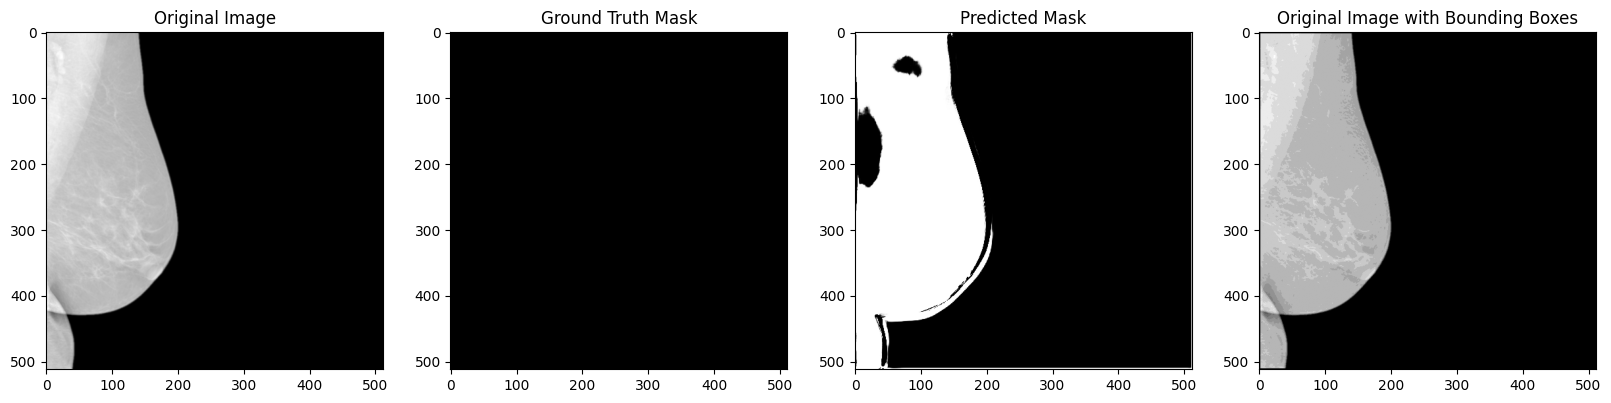

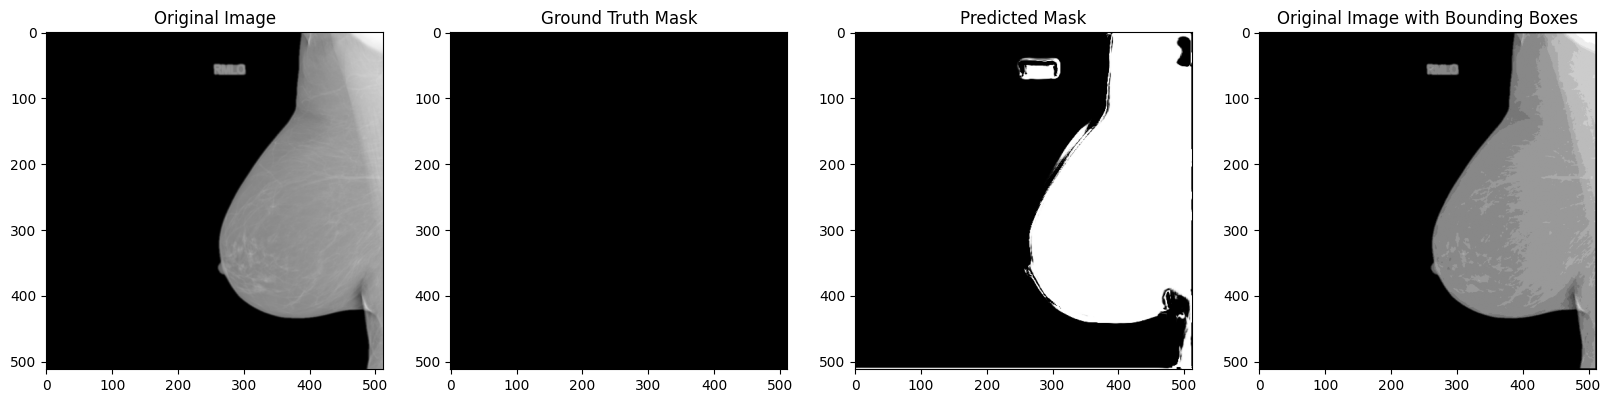

In [4]:
unet.visualize_predictions(num_images=10)


In [5]:
unet.model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
unet.evaluate()


  0%|          | 0/291 [00:00<?, ?it/s]

290/290 ━━━━━━━━━━━━━━━━━━━━ 734s 3s/step - accuracy: 0.7004 - loss: -4420.2568
Test Loss: -7437.51220703125, Test Accuracy: 0.7010373473167419
